In [1]:
import scipy.stats as stats
import scipy.stats as chi2

import pandas as pd;
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('questionnaire.csv')
df.head()

,SEQN,ACD011A,ACD011B,ACD011C,ACD040,ACD110,ALQ101,ALQ110,ALQ120Q,ALQ120U,...,WHD080U,WHD080L,WHD110,WHD120,WHD130,WHD140,WHQ150,WHQ030M,WHQ500,WHQ520
0,73557,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,3.0,...,NaN,40.0,270.0,200.0,69.0,270.0,62.0,NaN,NaN,NaN
1,73558,1.0,NaN,NaN,NaN,NaN,1.0,NaN,7.0,1.0,...,NaN,NaN,240.0,250.0,72.0,250.0,25.0,NaN,NaN,NaN
2,73559,1.0,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,...,NaN,NaN,180.0,190.0,70.0,228.0,35.0,NaN,NaN,NaN
3,73560,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,3.0
4,73561,1.0,NaN,NaN,NaN,NaN,1.0,NaN,0.0,NaN,...,NaN,NaN,150.0,135.0,67.0,170.0,60.0,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10175 entries, 0 to 10174
Columns: 953 entries, SEQN to WHQ520
dtypes: float64(944), int64(7), str(2)
memory usage: 74.0 MB


In [4]:
ID = 'SEQN'
confusion = 'DLQ040'   
ciggrate = 'SMD650'    

df = df[[ID, confusion, ciggrate]]  
df.columns = ['ID', 'confusion', 'ciggrate']

df.describe()

,ID,confusion,ciggrate
count,10175.000000,8780.000000,1248.000000
mean,78644.000000,1.901253,11.989583
std,2937.413829,0.314328,40.446177
min,73557.000000,1.000000,1.000000
25%,76100.500000,2.000000,4.000000
50%,78644.000000,2.000000,10.000000
75%,81187.500000,2.000000,15.000000
max,83731.000000,9.000000,999.000000


In [5]:
df.head(10)

,ID,confusion,ciggrate
0,73557,2.0,NaN
1,73558,2.0,1.0
2,73559,2.0,NaN
3,73560,2.0,NaN
4,73561,2.0,NaN
5,73562,2.0,NaN
6,73563,NaN,NaN
7,73564,2.0,NaN
8,73565,2.0,NaN
9,73566,2.0,1.0


In [6]:
df.groupby('confusion')['ciggrate'].sum()

confusion
1.0     2044.0
2.0    12919.0
7.0        0.0
9.0        0.0
Name: ciggrate, dtype: float64

## 1 means confusion ,2 means no-confusion 

In [7]:
df.isnull().sum() / len(df) * 100

ID            0.000000
confusion    13.710074
ciggrate     87.734644
dtype: float64

In [8]:
df['ciggrate'].value_counts(normalize = True) * 100

ciggrate
10.0     19.871795
20.0     17.948718
5.0       9.615385
1.0       8.573718
3.0       7.451923
2.0       6.650641
15.0      6.169872
4.0       5.208333
6.0       3.846154
7.0       3.205128
30.0      2.724359
12.0      2.403846
8.0       2.083333
40.0      0.961538
9.0       0.721154
25.0      0.400641
11.0      0.320513
13.0      0.320513
17.0      0.320513
18.0      0.240385
999.0     0.160256
50.0      0.160256
14.0      0.160256
16.0      0.080128
60.0      0.080128
27.0      0.080128
90.0      0.080128
29.0      0.080128
28.0      0.080128
Name: proportion, dtype: float64

In [9]:
df['confusion'].value_counts(normalize = True) * 100

confusion
2.0    89.965831
1.0    10.011390
7.0     0.011390
9.0     0.011390
Name: proportion, dtype: float64

In [10]:
df['ciggrate'].describe()

count    1248.000000
mean       11.989583
std        40.446177
min         1.000000
25%         4.000000
50%        10.000000
75%        15.000000
max       999.000000
Name: ciggrate, dtype: float64

In [11]:
df['confusion'].describe()

count    8780.000000
mean        1.901253
std         0.314328
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         9.000000
Name: confusion, dtype: float64

In [12]:
df['ciggrate'].unique()

array([ nan,   1.,  25.,  20.,  10.,   2.,   5.,   4.,  30.,   3.,   9.,
        15.,   7.,  12.,   6.,   8., 999.,  11.,  40.,  18.,  50.,  13.,
        16.,  17.,  14.,  60.,  27.,  90.,  29.,  28.])

In [13]:
df['confusion'].unique()

array([ 2., nan,  1.,  7.,  9.])

In [14]:
confusion_mode = df['confusion'].dropna().mode()
df.fillna({'confusion': confusion_mode[0]}, inplace = True)

,ID,confusion,ciggrate
0,73557,2.0,NaN
1,73558,2.0,1.0
2,73559,2.0,NaN
3,73560,2.0,NaN
4,73561,2.0,NaN
...,...,...,...
10170,83727,2.0,NaN
10171,83728,2.0,NaN
10172,83729,2.0,NaN
10173,83730,2.0,NaN


In [15]:
df.fillna({'ciggrate': 0}, inplace = True)

,ID,confusion,ciggrate
0,73557,2.0,0.0
1,73558,2.0,1.0
2,73559,2.0,0.0
3,73560,2.0,0.0
4,73561,2.0,0.0
...,...,...,...
10170,83727,2.0,0.0
10171,83728,2.0,0.0
10172,83729,2.0,0.0
10173,83730,2.0,0.0


In [16]:
smoker = df['ciggrate'].value_counts()
smoker

ciggrate
0.0      8927
10.0      248
20.0      224
5.0       120
1.0       107
3.0        93
2.0        83
15.0       77
4.0        65
6.0        48
7.0        40
30.0       34
12.0       30
8.0        26
40.0       12
9.0         9
25.0        5
11.0        4
13.0        4
17.0        4
18.0        3
999.0       2
50.0        2
14.0        2
16.0        1
60.0        1
27.0        1
90.0        1
29.0        1
28.0        1
Name: count, dtype: int64

In [17]:
# apply IQR on the tabel

# 1. Split the data
non_smokers = df[df['ciggrate'] == 0]
smokers = df[df['ciggrate'] > 0]

# 2. Calculate IQR ONLY on the smokers
Q1 = smokers['ciggrate'].quantile(0.25)
Q3 = smokers['ciggrate'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 3. Filter outliers ONLY from the smoker group
smokers_clean = smokers[(smokers['ciggrate'] >= lower) & (smokers['ciggrate'] <= upper)]

# 4. Combine Non-smokers + Clean Smokers back together
df = pd.concat([non_smokers, smokers_clean])

In [18]:
df['ciggrate'].value_counts()

ciggrate
0.0     8927
10.0     248
20.0     224
5.0      120
1.0      107
3.0       93
2.0       83
15.0      77
4.0       65
6.0       48
7.0       40
30.0      34
12.0      30
8.0       26
9.0        9
25.0       5
11.0       4
13.0       4
17.0       4
18.0       3
14.0       2
16.0       1
27.0       1
29.0       1
28.0       1
Name: count, dtype: int64

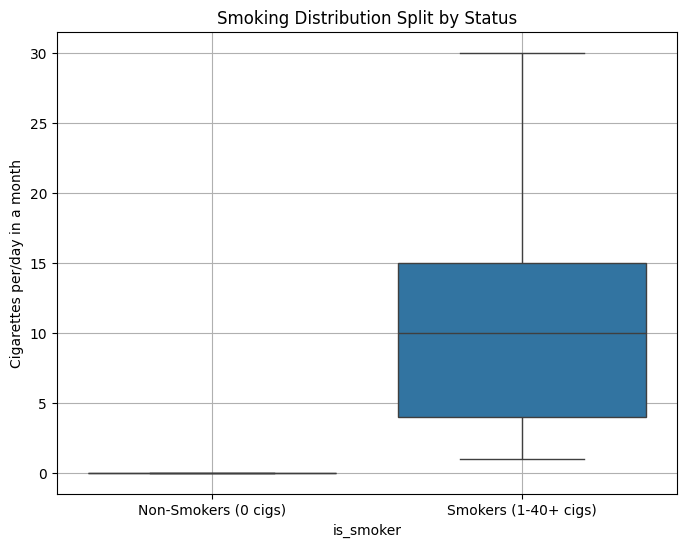

In [19]:
# Create a boolean column if you haven't already
df['is_smoker'] = df['ciggrate'] > 0

# Plot side-by-side boxplots
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_smoker', y='ciggrate', data=df)
plt.xticks([0, 1], ['Non-Smokers (0 cigs)', 'Smokers (1-40+ cigs)'])
plt.ylabel('Cigarettes per/day in a month')

plt.grid(True)
plt.title('Smoking Distribution Split by Status')
plt.show()

From above we can say that people who are smoker smokes as following:

50% smoke 10 cig a day, 75% smoke 15 cig a day, 25% smoke 4 cig a day 

In [20]:
confusion = df.groupby('confusion')['ciggrate'].sum()
confusion

confusion
1.0     1924.0
2.0    10311.0
7.0        0.0
9.0        0.0
Name: ciggrate, dtype: float64

confusion have 1,2,7,9. I have smoker and non smoker. am looking for if smoking cause the confusion so non smoker dont make scence to be here. because the factore that is supposed to determine is not even here. so I should remove te non smoker, and check for smoker only

In [21]:
df = df[df['confusion'].isin([1, 2])]
df['confusion'].unique()

array([2., 1.])

In [22]:
df['ciggrate'].unique()

array([ 0.,  1., 25., 20., 10.,  2.,  5.,  4., 30.,  3.,  9., 15.,  7.,
       12.,  6.,  8., 11., 18., 13., 16., 17., 14., 27., 29., 28.])

In [23]:
cause = pd.crosstab(df['confusion'], df['ciggrate'], normalize = True) * 100
cause

ciggrate,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,15.0,16.0,17.0,18.0,20.0,25.0,27.0,28.0,29.0,30.0
confusion,,,,,,,,,,,,,,,,,,,,,
1.0,6.95224,0.167405,0.078779,0.088626,0.078779,0.137863,0.049237,0.019695,0.029542,0.039389,...,0.108321,0.000000,0.009847,0.009847,0.393895,0.000000,0.000000,0.000000,0.000000,0.088626
2.0,80.93550,0.886263,0.738552,0.827179,0.561300,1.043821,0.423437,0.374200,0.226489,0.049237,...,0.649926,0.009847,0.029542,0.019695,1.811915,0.049237,0.009847,0.009847,0.009847,0.246184


In [24]:
def smoke_tier(smoke_column):
    Tier = [];
    for amount in df[smoke_column]:
        if amount == 0 :
            Tier.append('non-smoker')
        elif 1 <= amount <= 5:
            Tier.append('light-smoker')
        elif 6 <= amount <= 10:
            Tier.append('moderate')
        elif 11 <= amount <= 20:
            Tier.append('Heavy')
        else:
            Tier.append('Dangerous amount')
    return Tier;

df['Smoking_lvl'] = smoke_tier('ciggrate')

In [25]:
df.head()

,ID,confusion,ciggrate,is_smoker,Smoking_lvl
0,73557,2.0,0.0,False,non-smoker
2,73559,2.0,0.0,False,non-smoker
3,73560,2.0,0.0,False,non-smoker
4,73561,2.0,0.0,False,non-smoker
5,73562,2.0,0.0,False,non-smoker


In [26]:
cause_confusion = pd.crosstab(df['confusion'], df['Smoking_lvl'])
cause_confusion

Smoking_lvl,Dangerous amount,Heavy,light-smoker,moderate,non-smoker
confusion,,,,,
1.0,9,56,56,49,706
2.0,33,293,412,322,8219


As the data is showing that as the smoking amount is increase, it is creating problems with thinking and causing confusion

CHI-square Test will performed on this data set, reason being:
- There is 2 categorical data and have to find the relation between them which is smoking_lvl and confusion.
## Hypothesis will be :
- Null hypothesis -: There is no significance in decision making or confusion and amount of smoking a person do.
- Alt hypothesis -: There is significance in amount of ciggrate smoking and confusion or decision making.

In [27]:
cause_confusion.values

array([[   9,   56,   56,   49,  706],
       [  33,  293,  412,  322, 8219]])

In [28]:
val = stats.chi2_contingency(cause_confusion)
val

Chi2ContingencyResult(statistic=np.float64(55.41177359916897), pvalue=np.float64(2.6635276810352442e-11), dof=4, expected_freq=array([[3.62304284e+00, 3.01057607e+01, 4.03710487e+01, 3.20035451e+01,
        7.69896603e+02],
       [3.83769572e+01, 3.18894239e+02, 4.27628951e+02, 3.38996455e+02,
        8.15510340e+03]]))

In [29]:
val[2]

4

In [30]:
pval = val[1]
if pval < 0.05:
    print('True')

True


In [31]:
statisticval = val[0]
if statisticval > 9.48773:
    print('True')

True


In [32]:
criticalval = chi2.chi2.ppf(q = 1 - 0.05, df = val[2])
print(criticalval)

9.487729036781154


In [33]:
if pval < 0.05:
    print('Reject the null hypothesis');
else:
    print('accept the null hypothesis');

Reject the null hypothesis


In [34]:
if statisticval >= criticalval :
    print('Reject the null hypothesis');
else:
    print('accept the null hypothesis');

Reject the null hypothesis


## Clearly we reject the null hypothesis, that means there is significance in the amount of ciggrate consuption and confusion 
- so more consuption of ciggrate show more confusion in people
- lesser consuption can improve in mental clarity

In [35]:
df.head()

,ID,confusion,ciggrate,is_smoker,Smoking_lvl
0,73557,2.0,0.0,False,non-smoker
2,73559,2.0,0.0,False,non-smoker
3,73560,2.0,0.0,False,non-smoker
4,73561,2.0,0.0,False,non-smoker
5,73562,2.0,0.0,False,non-smoker


## Lets compair how demograpically, which age group fall in which smoking level in general.

In [36]:
df_age = pd.read_csv('demographic.csv')
df_age.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,73557,8,2,1,69,NaN,4,4,1.0,NaN,...,3.0,4.0,NaN,13281.237386,13481.042095,1,112,4.0,4.0,0.84
1,73558,8,2,1,54,NaN,3,3,1.0,NaN,...,3.0,1.0,1.0,23682.057386,24471.769625,1,108,7.0,7.0,1.78
2,73559,8,2,1,72,NaN,3,3,2.0,NaN,...,4.0,1.0,3.0,57214.803319,57193.285376,1,109,10.0,10.0,4.51
3,73560,8,2,1,9,NaN,3,3,1.0,119.0,...,3.0,1.0,4.0,55201.178592,55766.512438,2,109,9.0,9.0,2.52
4,73561,8,2,2,73,NaN,3,3,1.0,NaN,...,5.0,1.0,5.0,63709.667069,65541.871229,2,116,15.0,15.0,5.00


In [37]:
# this column is age in years
Age = 'RIDAGEYR'    

dfage = df_age[[ID, Age]]  
dfage.columns = ['ID', 'Age']

In [38]:
df = pd.merge(df, dfage, on='ID', how= 'inner')
df.head()

,ID,confusion,ciggrate,is_smoker,Smoking_lvl,Age
0,73557,2.0,0.0,False,non-smoker,69
1,73559,2.0,0.0,False,non-smoker,72
2,73560,2.0,0.0,False,non-smoker,9
3,73561,2.0,0.0,False,non-smoker,73
4,73562,2.0,0.0,False,non-smoker,56


In [39]:
smoking_age = round(df.groupby('Smoking_lvl')['Age'].mean(),2)
smoking_age

Smoking_lvl
Dangerous amount    48.31
Heavy               45.27
light-smoker        40.82
moderate            42.89
non-smoker          29.86
Name: Age, dtype: float64

In [40]:
confusion_age = df.groupby('confusion')['Age'].mean()
confusion_age

confusion
1.0    38.019406
2.0    30.824873
Name: Age, dtype: float64

## Now is it that the confusion is caused my amount of smoking or just by aging 
- Because the mean above is expanding on this perticular question

In [41]:
# Create age groups
df['age_group'] = pd.cut(df['Age'], bins=[18, 35, 50, 100], labels=['18-35', '36-50', '51+'])

# Confusion rate by Age Group AND Smoking Level
result = pd.crosstab([df['age_group'], df['Smoking_lvl']], df['confusion'], normalize='index') * 100
print(result)

confusion                         1.0        2.0
age_group Smoking_lvl                           
18-35     Dangerous amount  20.000000  80.000000
          Heavy             16.161616  83.838384
          light-smoker       5.294118  94.705882
          moderate          11.450382  88.549618
          non-smoker         6.426932  93.573068
36-50     Dangerous amount  29.411765  70.588235
          Heavy             11.607143  88.392857
          light-smoker      11.864407  88.135593
          moderate          16.161616  83.838384
          non-smoker         7.288136  92.711864
51+       Dangerous amount  15.000000  85.000000
          Heavy             20.300752  79.699248
          light-smoker      19.178082  80.821918
          moderate          11.940299  88.059701
          non-smoker        11.160914  88.839086


In [42]:
# UNDERSTNAD THE CODE FIRST
# MAKE SOME CONCLUSION